## Setup : Importing Necessary Librraries

In [126]:
# not always needed, but useful to make sure you install the needed libraries in the correct place
import sys
print(sys.executable)

/software/u22/anaconda/python3.9/bin/python


In [153]:
from liquipediapy import liquipediapy
from io import StringIO
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as sklr
from sklearn.metrics import r2_score

# I am not going to even pretend like I understand what is going on here, but this was all needed to get spark to work
import os, pyspark
spark_home = os.path.dirname(pyspark.__file__)
os.environ['SPARK_HOME'] = spark_home
os.environ['PATH']      = spark_home + os.pathsep + os.environ.get('PATH','')

import findspark
findspark.init()  

from pyspark.sql import SparkSession
from pyspark.sql.functions import concat_ws, to_date, current_date, datediff, col, regexp_replace, log1p
from pyspark.sql.functions import round as spark_round, avg, when
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.clustering import KMeans

spark = (
    SparkSession.builder
    .master("local[*]")      
    .appName("R6Stats")
    .getOrCreate()
)

## Milestone 1 : Data Collection and Problem Definitons

In [128]:
# grab the table from https://liquipedia.net/rainbowsix/Portal:Statistics/Player_earnings and store it in a DataFrame
client = liquipediapy('my_r6_stats_app', 'rainbowsix')
soup, redirect = client.parse('Portal:Statistics/Player_earnings')
html_buf = StringIO(str(soup))
df = spark.createDataFrame(pd.read_html(html_buf)[0])

# output to check table pulled sucessfully
df.show(5, truncate=False)

+---+-------+------------+----------+----------+----------+--------+
|#  |Player |Achievements|Unnamed: 3|Unnamed: 4|Unnamed: 5|Earnings|
+---+-------+------------+----------+----------+----------+--------+
|1  |Shaiiko|NaN         |20        |14        |6         |$882,912|
|2  |BriD   |NaN         |16        |18        |3         |$750,959|
|3  |Cyber  |NaN         |10        |2         |10        |$593,322|
|4  |HerdsZ |NaN         |5         |9         |8         |$557,192|
|5  |Kheyze |NaN         |6         |10        |8         |$557,089|
+---+-------+------------+----------+----------+----------+--------+
only showing top 5 rows



In [129]:
# grab the table from https://liquipedia.net/rainbowsix/Birthday_list and store it in a DataFrame
soup, redirect = client.parse('Birthday_list')
html_buf = StringIO(str(soup))

# define a schema so it can handle different tpyes in the same column (i.e. string or int and NaN values)
schema = StructType([
  StructField("Birth year", IntegerType(), True),
  StructField("Month/Day", StringType(),  True),
  StructField("ID",        StringType(),  True),
  StructField("Name",      StringType(),  True),
])

bdf = spark.createDataFrame(pd.read_html(html_buf)[0], schema=schema)

# output to check table pulled sucessfully
bdf.show(5, truncate=False)

+----------+------------+-------+---------------+
|Birth year|Month/Day   |ID     |Name           |
+----------+------------+-------+---------------+
|1977      |March 25    |DnA    |David Thomas   |
|1977      |August 05   |Tomozoh|Tomohisa Yamano|
|1980      |September 16|qeP    |Ricardo Fugi   |
|1981      |March 15    |DraZ   |Razig Abida    |
|1981      |November 18 |GaelV8 |Gaël Trico     |
+----------+------------+-------+---------------+
only showing top 5 rows



In [130]:
# compute age in years (integer)
bday_info = (
    bdf
    # convert birth year and month/dat columns into actual birth date string
    .withColumn(
        "birthdate",
        to_date(concat_ws(" ", col("Birth year").cast("string"), col("Month/Day")), "yyyy MMMM d")
    )
    # calculate actual age using birthdate
    .withColumn(
        "age",
        (datediff(current_date(), col("birthdate")) / 365.25).cast("int")
    )
    # select the needed columns to merge into df
    .select(
        col("ID"),
        col("Name"),
        "age"
    )
)

# merge the new info into the old DataFrame
df = (
    df
    .join(bday_info, df.Player == bday_info.ID, how="left")
    .drop("ID")
)

# reorder the columns
front = ['#', 'age','Name','Player']
rest  = [c for c in df.columns if c not in front]
df = df.select(*front, *rest)

# output to verify merge
df.show(5, truncate=False)

+---+---+---------------+-------+------------+----------+----------+----------+--------+
|#  |age|Name           |Player |Achievements|Unnamed: 3|Unnamed: 4|Unnamed: 5|Earnings|
+---+---+---------------+-------+------------+----------+----------+----------+--------+
|5  |22 |Diego Zanello  |Kheyze |NaN         |6         |10        |8         |$557,089|
|4  |24 |Gustavo Herdina|HerdsZ |NaN         |5         |9         |8         |$557,192|
|3  |26 |Jaime Ramos    |Cyber  |NaN         |10        |2         |10        |$593,322|
|6  |22 |João Vitor     |Jv92   |NaN         |8         |6         |10        |$556,901|
|1  |26 |Stéphane Lebleu|Shaiiko|NaN         |20        |14        |6         |$882,912|
+---+---+---------------+-------+------------+----------+----------+----------+--------+
only showing top 5 rows



In [131]:
# export raw DataFrame to a .csv file
(
  df
    .repartition(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv("raw_player_earnings")
)

## Milestone 2 : Pre-Processing & Exploratory Data Analysis

In [132]:
# show columns and thier types
df.printSchema()

# show basic numeric summaries
df.describe().show()

# drop duplicates and output number of duplicate rows
original_count = df.count()
dropped_duplicates_count = df.dropDuplicates().count()
print(f"Duslpicate rows: {original_count - dropped_duplicates_count}")

root
 |-- #: long (nullable = true)
 |-- age: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Player: string (nullable = true)
 |-- Achievements: double (nullable = true)
 |-- Unnamed: 3: long (nullable = true)
 |-- Unnamed: 4: long (nullable = true)
 |-- Unnamed: 5: long (nullable = true)
 |-- Earnings: string (nullable = true)

+-------+-----------------+------------------+------------+------+------------+------------------+------------------+------------------+--------+
|summary|                #|               age|        Name|Player|Achievements|        Unnamed: 3|        Unnamed: 4|        Unnamed: 5|Earnings|
+-------+-----------------+------------------+------------+------+------------+------------------+------------------+------------------+--------+
|  count|             1668|               989|         989|  1668|        1668|              1668|              1668|              1668|    1668|
|   mean|831.8363309352518|24.949443882709808|         NaN|  null

In [133]:

# fill NaN values and fix value types
df = (
    df
        # drop the Achievements column as it's all NaN values and not needed anyways
        .drop('Achievements')
        # drop $ and commas, then cast to int
        .withColumn('earnings', regexp_replace(col('Earnings'), '[$,]', '').cast('int'))
        # fill NaN values
        .fillna({
            'Name': 'Unknown',
            'age': df.select(avg(col('age'))).first()[0]
        })
        # cast age to int
        .withColumn('age', spark_round(col('age')).cast('int'))
)

# rename remaining columns
for old, new in {
    '#':          'rank',
    'Name':       'player_name',
    'Player':     'gamertag',
    'Unnamed: 3': 'num_frst',
    'Unnamed: 4': 'num_scnd',
    'Unnamed: 5': 'num_thrd',
}.items():
    df = df.withColumnRenamed(old, new)

# output to ensure fixes were correctly made
df.show(5, truncate=False)

+----+---+---------------+--------+--------+--------+--------+--------+
|rank|age|player_name    |gamertag|num_frst|num_scnd|num_thrd|earnings|
+----+---+---------------+--------+--------+--------+--------+--------+
|5   |22 |Diego Zanello  |Kheyze  |6       |10      |8       |557089  |
|4   |24 |Gustavo Herdina|HerdsZ  |5       |9       |8       |557192  |
|3   |26 |Jaime Ramos    |Cyber   |10      |2       |10      |593322  |
|6   |22 |João Vitor     |Jv92    |8       |6       |10      |556901  |
|1   |26 |Stéphane Lebleu|Shaiiko |20      |14      |6       |882912  |
+----+---+---------------+--------+--------+--------+--------+--------+
only showing top 5 rows



In [134]:
# calc and insert new features
df = (
    df
        # insert new column of total podium placements
        .withColumn('num_top3', col('num_frst') + col('num_scnd') + col('num_thrd'))
        # insert new column of earnings per podium placement, set to zero when no podium placements
        .withColumn(
            'earnings_per_top3', 
            when(col("num_top3") == 0, 0)
            .otherwise((col("earnings") / col("num_top3")).cast("int")))
)

# reorder columns
back = ['num_top3', 'earnings','earnings_per_top3']
rest  = [c for c in df.columns if c not in back]
df = df.select(*rest, *back)

df.show(5, truncate=False)

+----+---+------------------------------+--------+--------+--------+--------+--------+--------+-----------------+
|rank|age|player_name                   |gamertag|num_frst|num_scnd|num_thrd|num_top3|earnings|earnings_per_top3|
+----+---+------------------------------+--------+--------+--------+--------+--------+--------+-----------------+
|51  |31 |Paulo Augusto Arneiro Lourenço|psk1    |8       |3       |8       |19      |275083  |14478            |
|74  |22 |Júlio Gabriel                 |L0BIN   |3       |8       |5       |16      |192554  |12034            |
|143 |26 |Nathan Valenti                |nvK     |5       |5       |2       |12      |93855   |7821             |
|134 |23 |Taiyo Kitano                  |Taiyou  |12      |1       |4       |17      |100893  |5934             |
|142 |22 |Aoi Tanigawa                  |Wqsyo1  |12      |1       |4       |17      |94165   |5539             |
+----+---+------------------------------+--------+--------+--------+--------+--------+--

Kept 1419 of 1668 rows after outlier removal


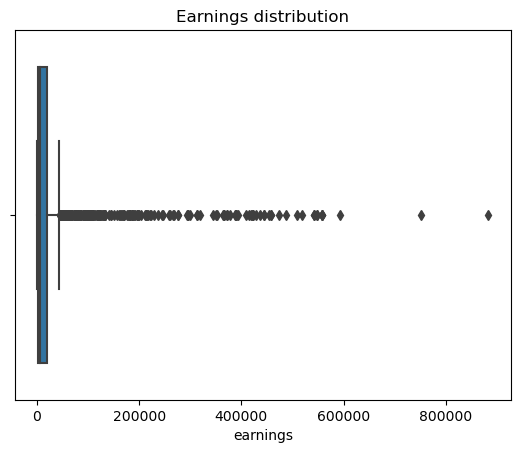

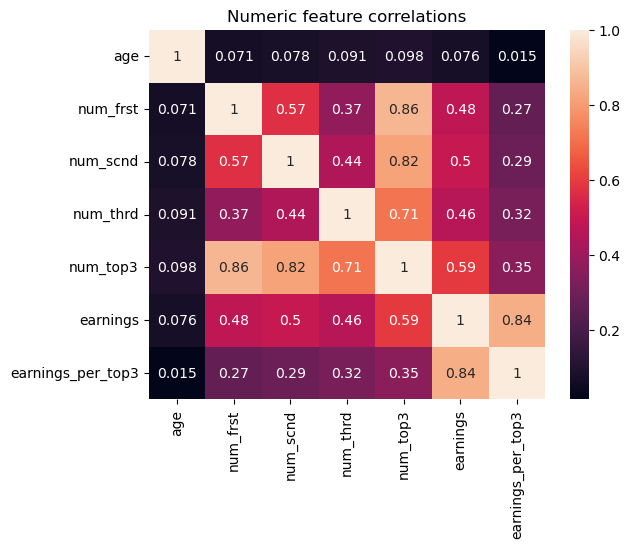

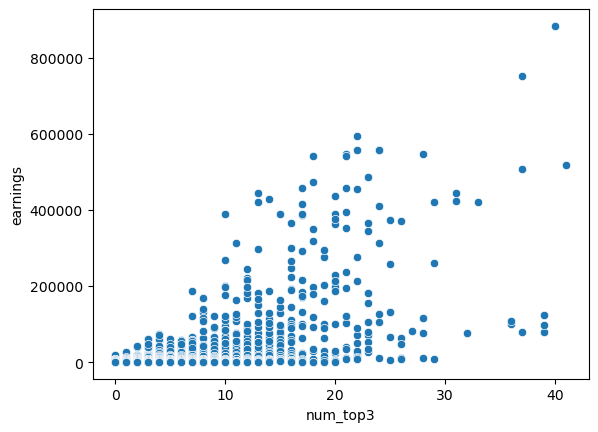

In [ ]:
# calc IQR bounds
Q1, Q3 = df.stat.approxQuantile('earnings', [0.25, 0.75], 0.0)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# create new clipped DataFrame without outliers
original_count = df.count()
clipped_df     = df.filter((col("earnings") >= lower) & (col("earnings") <= upper))
clipped_count  = clipped_df.count()
print(f"Kept {clipped_count} of {original_count} rows after outlier removal")

# boxplot of the earnings
sns.boxplot(x = "earnings", data = df.select('earnings').toPandas())
plt.title("Earnings distribution")
plt.show()

# correlation matrix & heatmap of numeric features
num_df = df.select(
    "age",
    "num_frst",
    "num_scnd",
    "num_thrd",
    "num_top3",
    "earnings",
    "earnings_per_top3"
).toPandas()
corr = num_df.corr()
sns.heatmap(corr, annot=True)
plt.title("Numeric feature correlations")
plt.show()

# scatter earnings vs. num_top3
sns.scatterplot(x = 'num_top3', y = 'earnings', data = num_df)
plt.show()

In [136]:
df = (
    df
        # heavily skewed to the right, so create a new feature of log earnings to help tame it 
        .withColumn("log_earnings", log1p(col("earnings")))
        # also create a feature that flags outliers
        .withColumn("is_outlier", ~col("earnings").between(lower, upper))
)

df.show(5, truncate=False)

+----+---+------------------------------+--------+--------+--------+--------+--------+--------+-----------------+------------------+----------+
|rank|age|player_name                   |gamertag|num_frst|num_scnd|num_thrd|num_top3|earnings|earnings_per_top3|log_earnings      |is_outlier|
+----+---+------------------------------+--------+--------+--------+--------+--------+--------+-----------------+------------------+----------+
|51  |31 |Paulo Augusto Arneiro Lourenço|psk1    |8       |3       |8       |19      |275083  |14478            |12.52483178455242 |true      |
|74  |22 |Júlio Gabriel                 |L0BIN   |3       |8       |5       |16      |192554  |12034            |12.168137106187137|true      |
|143 |26 |Nathan Valenti                |nvK     |5       |5       |2       |12      |93855   |7821             |11.449516971777177|true      |
|134 |23 |Taiyo Kitano                  |Taiyou  |12      |1       |4       |17      |100893  |5934             |11.521825739756949|true

Intercept: 7.7956
Slope:     0.1572
R² score:  0.4259


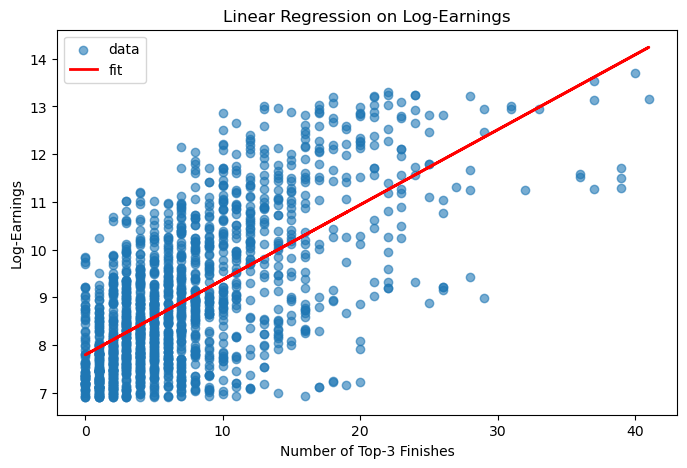

In [137]:
# convert Spark DataFrame "df" to a Panda DataFrame to use for the linear regressions
panda_df = df.toPandas()

# create a linear regression of the full DataFrame, but using the log earnings
X = panda_df['num_top3'].values.reshape(-1, 1)
y = panda_df['log_earnings']

model = sklr()
model.fit(X, y)
y_pred = model.predict(X)

# output metrics
print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope:     {model.coef_[0]:.4f}")
print(f"R² score:  {r2_score(y, y_pred):.4f}")

# plot scatters and regression lines to compare results
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6, label='data')
plt.plot(X, y_pred, color='red', linewidth=2, label='fit')
plt.xlabel("Number of Top-3 Finishes")
plt.ylabel("Log-Earnings")
plt.title("Linear Regression on Log-Earnings")
plt.legend()
plt.show()

In [138]:
# done cleaning and pre-processing, so export DataFrame to a .csv file
(
  df
    .repartition(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv("processed_player_earnings")
)

## Milestone 3 : Modeling and Implementation

Intercept: 10.9886
Slope:     0.0475
R² score:  0.2233


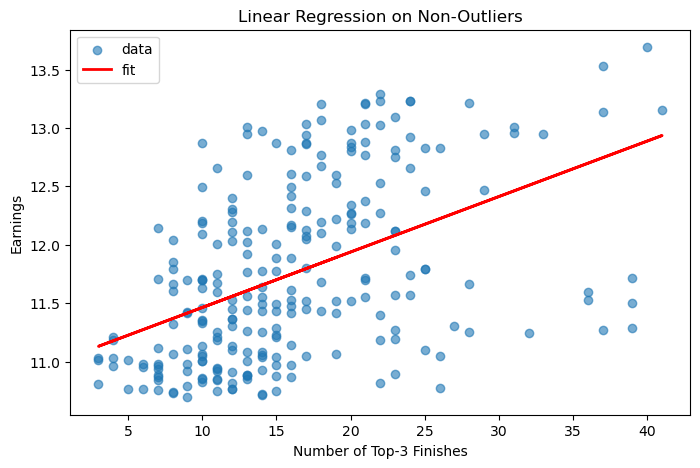

In [139]:
# create another linear regression, but this time with the clipped dataframe
df_no_out = panda_df[panda_df['is_outlier']].copy()

X_no = df_no_out['num_top3'].values.reshape(-1, 1)
y_no = df_no_out['log_earnings']

model_no = sklr().fit(X_no, y_no)
y_no_pred = model_no.predict(X_no)

# output the same metrics to compare to those of the log-earnings linear regression
print(f"Intercept: {model_no.intercept_:.4f}")
print(f"Slope:     {model_no.coef_[0]:.4f}")
print(f"R² score:  {r2_score(y_no, y_no_pred):.4f}")

# also plot this linear regression once again to comapre to the log-earnings one
plt.figure(figsize=(8,5))
plt.scatter(X_no, y_no, alpha=0.6, label='data')
plt.plot(X_no, y_no_pred, color='red', linewidth=2, label='fit')
plt.xlabel("Number of Top-3 Finishes")
plt.ylabel("Earnings")
plt.title("Linear Regression on Non-Outliers")
plt.legend()
plt.show()

Intercept:          7.3980
Slope (num_top3):   0.1565
Slope (age):        0.0164
R² score:           0.4269


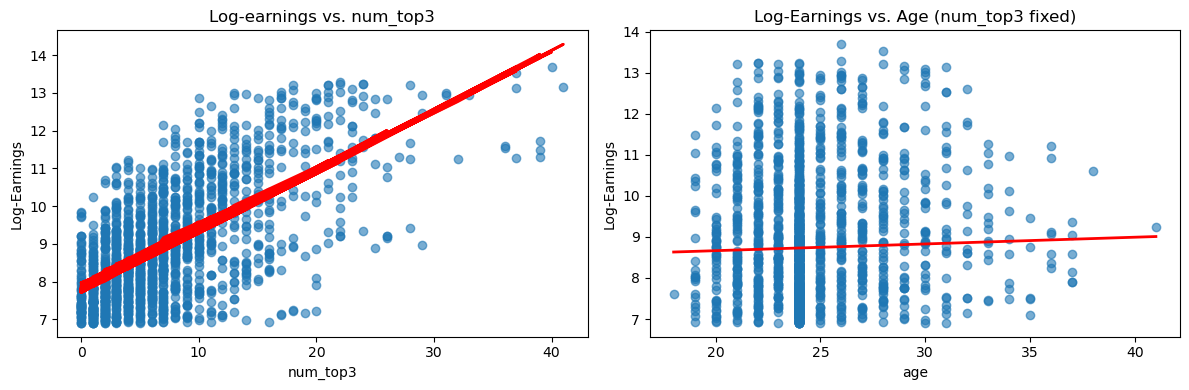

In [140]:
# create a two-feature linear regression (num_top3 and age) to show that age has little-to-no predictive power
X = panda_df[['num_top3','age']]
y = panda_df['log_earnings']

# avoid a feature-name mismatch warning by converting to plain NumPy arrays for both .fit() and .predict()
model = sklr().fit(X.values, y.values)
y_pred = model.predict(X.values)

# output the same metrics to compare to those of the log-earnings linear regression
print(f"Intercept:          {model.intercept_:.4f}")
print(f"Slope (num_top3):   {model.coef_[0]:.4f}")
print(f"Slope (age):        {model.coef_[1]:.4f}")
print(f"R² score:           {r2_score(y, y_pred):.4f}")

# scatter / partial‐regression plots
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].scatter(panda_df['num_top3'], y, alpha = 0.6)
axes[0].plot(panda_df['num_top3'], y_pred, color='r', lw = 2)
axes[0].set_title("Log-earnings vs. num_top3")
axes[1].scatter(panda_df['age'], y, alpha = 0.6)

# show the age effect holding num_top3 constant:
# compute predictions at median podium count
median_top3 = panda_df['num_top3'].median()
age_grid    = np.linspace(panda_df['age'].min(), panda_df['age'].max(), 50)
X_line      = np.column_stack([np.repeat(median_top3,50), age_grid])
y_line      = model.predict(X_line)
axes[1].plot(age_grid, y_line, color='r', lw=2)
axes[1].set_title("Log-Earnings vs. Age (num_top3 fixed)")

for ax in axes:
    ax.set_xlabel(ax is axes[0] and 'num_top3' or 'age')
    ax.set_ylabel('Log-Earnings')
plt.tight_layout()
plt.show()


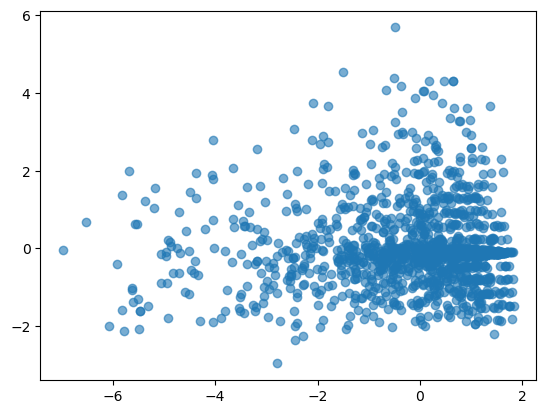

+----------+-----+
|prediction|count|
+----------+-----+
|         1|  982|
|         3|  183|
|         2|  123|
|         0|  380|
+----------+-----+



In [ ]:
# this was mostly a sanity check just making sure that the players were not easily and clearly clusterable 
# I thought about using which cluster the player falls into as another feature in the next steps, but decided not to

feat_cols = [
    "age",
    "num_top3",
    "earnings_per_top3",
    "log_earnings"
]
assembler = VectorAssembler(inputCols = feat_cols, outputCol = "rawFeatures")
df_feats = assembler.transform(df)
scaler = StandardScaler(inputCol = "rawFeatures", outputCol = "features", withMean = True, withStd = True)
df_scaled = scaler.fit(df_feats).transform(df_feats)

# PCA just to visualtize a 2D scatter
pca = PCA(k = 2, inputCol = "features", outputCol = "pc")
pcs = pca.fit(df_scaled).transform(df_scaled)
pdf = pcs.select("pc").toPandas()
X2 = np.stack(pdf["pc"].values)
plt.scatter(X2[:,0], X2[:,1], alpha=0.6); plt.show()

# K-Means clustering, once again seed = 42 for reproducability
km = KMeans(k = 4, seed = 42, featuresCol="features")
model = km.fit(df_scaled)
clustered = model.transform(df_scaled)
clustered.groupBy("prediction").count().show()


In [ ]:
# split 80% train / 20% test -- seed = 42 for reproducible results
train_df, test_df = df.randomSplit([0.8, 0.2], seed = 42)

# assemble all the numeric features I want to use 
feature_cols = [
    "age",
    "num_frst",
    "num_scnd",
    "num_thrd",
    "num_top3",
    "earnings_per_top3"
]
assembler = VectorAssembler(inputCols = feature_cols, outputCol = "features")

# create a Ridge LinearRegression
lr = LinearRegression(
    featuresCol = "features",
    labelCol = "log_earnings",
    predictionCol = "prediction"
)

# and then a RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol = "features",
    labelCol = "log_earnings",
    predictionCol = "prediction",
    seed = 42
)

# create the pipeline for each
pipe_lr = Pipeline(stages=[assembler, lr])
pipe_rf = Pipeline(stages=[assembler, rf])

# and the parameter grids
grid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam,       [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam,[0.0,  0.5]) \
    .build()

grid_rf = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# and the evaluator
evaluator = RegressionEvaluator(
    labelCol = "log_earnings",
    predictionCol = "prediction"
)

# and the cross‐validators with three folds
cv_lr = CrossValidator(
    estimator = pipe_lr,
    estimatorParamMaps = grid_lr,
    evaluator = evaluator.setMetricName("rmse"),
    numFolds = 3,
    parallelism = 2
)
cv_rf = CrossValidator(
    estimator = pipe_rf,
    estimatorParamMaps = grid_rf,
    evaluator = evaluator.setMetricName("rmse"),
    numFolds = 3,
    parallelism = 2
)

# fit the models on training data
cv_model_lr = cv_lr.fit(train_df)
cv_model_rf = cv_rf.fit(train_df)

# best‐model predictions on test set
pred_lr = cv_model_lr.bestModel.transform(test_df)
pred_rf = cv_model_rf.bestModel.transform(test_df)

# compute and output the RMSE & R2
for name, preds in [("LinearReg", pred_lr), ("RandomForest", pred_rf)]:
    rmse = evaluator.setMetricName("rmse").evaluate(preds)
    r2 = evaluator.setMetricName("r2").evaluate(preds)
    print(f"{name:15s} → Test RMSE: {rmse:.4f},  R²: {r2:.4f}")


25/05/02 23:19:38 WARN DAGScheduler: Broadcasting large task binary with size 1035.6 KiB


25/05/02 23:19:41 WARN DAGScheduler: Broadcasting large task binary with size 1411.0 KiB


25/05/02 23:20:03 WARN DAGScheduler: Broadcasting large task binary with size 1573.8 KiB


25/05/02 23:20:06 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


25/05/02 23:20:13 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB


...

25/05/02 23:21:45 WARN DAGScheduler: Broadcasting large task binary with size 1399.4 KiB


25/05/02 23:22:07 WARN DAGScheduler: Broadcasting large task binary with size 1592.9 KiB


25/05/02 23:22:10 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


25/05/02 23:22:17 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB


25/05/02 23:22:26 WARN DAGScheduler: Broadcasting large task binary with size 1640.4 KiB
25/05/02 23:22:27 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/05/02 23:22:27 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
LinearReg       → Test RMSE: 0.7429,  R²: 0.7592
RandomForest    → Test RMSE: 0.2686,  R²: 0.9685


## Milestone 4 : Model Evaluation and Optimization

In [152]:
# add mae and mse metrics to the evaluation
for name, preds in [("Ridge", pred_lr), ("RandomForest", pred_rf)]:
    rmse = evaluator.setMetricName("rmse").evaluate(preds)
    r2 = evaluator.setMetricName("r2").evaluate(preds)
    mae = evaluator.setMetricName("mae").evaluate(preds)
    mse = evaluator.setMetricName("mse").evaluate(preds)
    print(f"{name:15s} → Test RMSE = {rmse:.4f},  R² = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}")

Ridge           → Test RMSE = 0.7429,  R² = 0.7592, MAE = 0.6142, MSE = 0.5519
RandomForest    → Test RMSE = 0.2686,  R² = 0.9685, MAE = 0.1700, MSE = 0.0721


In [ ]:
# set up Random Forest and pipeline like in milestone 3 
feature_cols = [
    "age",
    "num_frst",
    "num_scnd",
    "num_thrd",
    "num_top3",
    "earnings_per_top3"
]
assembler = VectorAssembler(inputCols = feature_cols, outputCol = "features")

rf = RandomForestRegressor(
    featuresCol = "features",
    labelCol = "log_earnings",
    predictionCol = "prediction",
    seed = 42
)

pipeline = Pipeline(stages = [assembler, rf])

# construct a bigger param grid
paramGrid = (
    ParamGridBuilder()
      .addGrid(rf.numTrees, [50, 100])
      .addGrid(rf.maxDepth, [5, 10])
      .addGrid(rf.minInstancesPerNode, [1, 5])
      .addGrid(rf.featureSubsetStrategy, ["auto","sqrt"])
      .build()
)

# set up an evaluator, in this case with RMSE as the metric of choice
evaluator = RegressionEvaluator(
    labelCol = "log_earnings",
    predictionCol = "prediction",
    metricName = "rmse"
)

# use TrainValidationSplit because it's faster than full CrossValidator on big grids
tvs = TrainValidationSplit(
    estimator = pipeline,
    estimatorParamMaps = paramGrid,
    evaluator = evaluator,
    trainRatio = 0.8,
    parallelism = spark.sparkContext.defaultParallelism
)

# run the tuning
tvs_model = tvs.fit(train_df)

# grab the best‐found model and its RF stage
best_model = tvs_model.bestModel
best_rf = best_model.stages[-1]

25/05/03 02:02:06 WARN CacheManager: Asked to cache already cached data.
25/05/03 02:02:06 WARN CacheManager: Asked to cache already cached data.


25/05/03 02:02:22 WARN DAGScheduler: Broadcasting large task binary with size 1029.6 KiB


25/05/03 02:02:32 WARN DAGScheduler: Broadcasting large task binary with size 1052.7 KiB


25/05/03 02:02:43 WARN DAGScheduler: Broadcasting large task binary with size 1842.5 KiB


25/05/03 02:02:51 WARN DAGScheduler: Broadcasting large task binary with size 1916.8 KiB


...

25/05/03 02:38:53 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


25/05/03 02:38:55 WARN DAGScheduler: Broadcasting large task binary with size 29.0 MiB
25/05/03 02:38:55 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB


25/05/03 02:38:56 WARN DAGScheduler: Broadcasting large task binary with size 1798.6 KiB
25/05/03 02:38:57 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
25/05/03 02:38:57 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/05/03 02:38:58 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB


25/05/03 02:38:59 WARN DAGScheduler: Broadcasting large task binary with size 30.1 MiB
25/05/03 02:38:59 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
25/05/03 02:38:59 WARN DAGScheduler: Broadcasting large task binary with size 1854.0 KiB


25/05/03 02:39:00 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
25/05/03 02:39:00 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
25/05/03 02:39:00 WARN DAGScheduler: Broadcasting large task binary with size 5.8 MiB
25/05/03 02:39:01 WARN DAGScheduler: Broadcasting large task binary with size 6.9 MiB
25/05/03 02:39:01 WARN DAGScheduler: Broadcasting large task binary with size 4.7 MiB
25/05/03 02:39:02 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
25/05/03 02:39:02 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
25/05/03 02:39:02 WARN DAGScheduler: Broadcasting large task binary with size 1074.9 KiB
25/05/03 02:39:02 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/05/03 02:39:03 WARN DAGScheduler: Broadcasting large task binary with size 7.5 MiB
25/05/03 02:39:03 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB
25/05/03 02:39:03 WARN DAGScheduler: Broadcasting l

In [ ]:
# output the best of each
print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getMaxDepth)
print("Best minInstancesPerNode:", best_rf.getMinInstancesPerNode())
print("Best featureSubsetStrategy:", best_rf.getFeatureSubsetStrategy())

# evaluate final on the true test set
predictions = best_model.transform(test_df)
rmse = evaluator.setMetricName("rmse").evaluate(predictions)
r2 = evaluator.setMetricName("r2") .evaluate(predictions)
mae = evaluator.setMetricName("mae") .evaluate(predictions)
mse = evaluator.setMetricName("mse") .evaluate(predictions)
print(f"{name:15s} → Test RMSE = {rmse:.4f},  R² = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}")

Best numTrees: 100
Best maxDepth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestRegressionModel: uid=RandomForestRegressor_676f13b382e2, numTrees=100, numFeatures=6>
Best minInstancesPerNode: 1
Best featureSubsetStrategy: sqrt
RandomForest    → Test RMSE = 0.2157,  R² = 0.9797, MAE = 0.1147, MSE = 0.0465
